<u>**Plotting figure 2 of the article**</u>

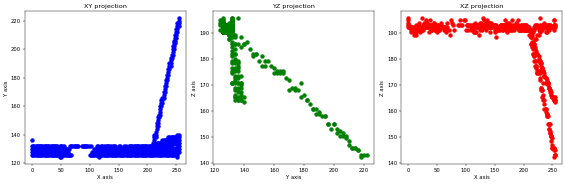

In [60]:
import numpy as np
import matplotlib.pyplot as plt
# old_data = np.loadtxt('track_event_21_0.txt')
data = np.loadtxt('cluster_0_data.txt')

# Extract X, Y, Z components from the data array
x = data[:, 0]
y = data[:, 1]
z = data[:, 2] 

data = np.column_stack((x, y, z))

# Create a figure with 3 subplots (for xy, yz, and xz projections)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: XY projection (x vs y)
axes[0].scatter(x, y, c='blue', s=50)
axes[0].set_xlabel('X axis')
axes[0].set_ylabel('Y axis')
axes[0].set_title('XY projection')

# Plot 2: YZ projection (y vs z)
axes[1].scatter(y, z, c='green', s=50)
axes[1].set_xlabel('Y axis')
axes[1].set_ylabel('Z axis')
axes[1].set_title('YZ projection')

# Plot 3: XZ projection (x vs z)
axes[2].scatter(x, z, c='red', s=50)
axes[2].set_xlabel('X axis')
axes[2].set_ylabel('Z axis')
axes[2].set_title('XZ projection')

# Adjust layout to avoid overlapping
plt.tight_layout()

# Show the plots
plt.show()


In [61]:
import numpy as np

In [64]:
import numpy as np

def unique_rows_with_tol(arr, tol=1e-2):
    # Round to tolerance to stabilize comparisons
    return np.unique(np.round(arr / tol) * tol, axis=0)

data1 = unique_rows_with_tol(np.loadtxt('track_event_21_0.txt')[:, :3])
data2 = unique_rows_with_tol(np.loadtxt('cluster_0_data.txt')[:, :3])

# Same as before
set1 = set(map(tuple, data1))
set2 = set(map(tuple, data2))

only_in_file1 = np.array(list(set1 - set2))
only_in_file2 = np.array(list(set2 - set1))

print("Rows only in track_event_21_0.txt:")
print(only_in_file1)

print("\nRows only in cluster_0_data.txt:")
print(only_in_file2)

print("Number of rows only in track_event_21_0.txt:", len(only_in_file1), len(data1[:,0]))
print("Number of rows only in cluster_0_data.txt:", len(only_in_file2), len(data2[:,0]))

Rows only in track_event_21_0.txt:
[[222.   132.   201.73]
 [242.   138.   187.39]
 [166.   130.   212.99]
 ...
 [220.   132.   203.78]
 [254.   130.   212.99]
 [176.   126.   210.94]]

Rows only in cluster_0_data.txt:
[[250.   138.   165.18]
 [ 72.   132.   189.31]
 [186.   130.   193.02]
 ...
 [ 10.   128.   191.17]
 [236.   182.   164.26]
 [244.   136.   168.9 ]]
Number of rows only in track_event_21_0.txt: 548 548
Number of rows only in cluster_0_data.txt: 548 548


In [65]:
import numpy as np
from scipy.spatial import cKDTree

# Load both files
file1 = np.loadtxt('track_event_21_0.txt')
file2 = np.loadtxt('cluster_0_data.txt')

# Extract XY (columns 0 and 1)
xy1 = file1[:, :2]
xy2 = file2[:, :2]

# Extract Z (column 2)
z1 = file1[:, 2]
z2 = file2[:, 2]

# Build KDTree for file2 XY
tree = cKDTree(xy2)

# For every row in file1, find closest XY in file2
distances, indices = tree.query(xy1)

print("X1   Y1   Z1    Z2    Z1/Z2")
print("-" * 50)

for i in range(len(file1)):
    idx2 = indices[i]  # closest row in file2
    x1, y1 = xy1[i]
    z1_i = z1[i]
    z2_i = z2[idx2]
    ratio = z1_i / z2_i if z2_i != 0 else np.nan
    
    print(f"{x1:.3f} {y1:.3f} {z1_i:.3f}   {z2_i:.3f}   {ratio:.4f}")

X1   Y1   Z1    Z2    Z1/Z2
--------------------------------------------------
226.000 126.000 210.944   191.168   1.1034
224.000 126.000 211.968   192.096   1.1034
228.000 126.000 216.064   195.808   1.1034
228.000 136.000 196.608   178.176   1.1034
230.000 136.000 195.584   177.248   1.1034
228.000 128.000 212.992   193.024   1.1034
230.000 128.000 211.968   192.096   1.1034
228.000 130.000 209.920   190.240   1.1034
230.000 130.000 210.944   191.168   1.1034
228.000 132.000 197.632   179.104   1.1034
230.000 132.000 196.608   178.176   1.1034
228.000 134.000 197.632   179.104   1.1034
230.000 134.000 196.608   178.176   1.1034
230.000 174.000 186.368   168.896   1.1034
228.000 168.000 190.464   172.608   1.1034
230.000 170.000 185.344   167.968   1.1034
228.000 170.000 189.440   171.680   1.1034
230.000 172.000 186.368   168.896   1.1034
224.000 164.000 193.536   175.392   1.1034
226.000 166.000 193.536   175.392   1.1034
228.000 166.000 192.512   174.464   1.1034
224.000 160.000 19

Initial Means (from K-Means):
[[ 34.32857143 129.02857143 192.11588571]
 [222.85714286 133.34285714 184.97691429]
 [242.25531915 195.91489362 155.96323404]
 [141.9602649  128.74172185 192.41557616]]

Initial Covariances (from K-Means assignments):
[[[ 4.73013566e+02  1.99054471e+00  1.79600904e+00]
  [ 1.99054471e+00  5.84090442e+00  3.79974512e-01]
  [ 1.79600904e+00  3.79974512e-01  1.35643118e+00]]

 [[ 3.84716336e+02  2.09295967e+01 -9.36220697e+01]
  [ 2.09295967e+01  7.08196856e+01 -4.34368700e+01]
  [-9.36220697e+01 -4.34368700e+01  8.68037565e+01]]

 [[ 6.39333950e+01  1.23935245e+02 -7.09065828e+01]
  [ 1.23935245e+02  2.44340426e+02 -1.39235197e+02]
  [-7.09065828e+01 -1.39235197e+02  8.07792185e+01]]

 [[ 6.03011744e+02 -6.10331126e-01 -2.91969695e+00]
  [-6.10331126e-01  4.99284768e+00  2.43943135e-01]
  [-2.91969695e+00  2.43943135e-01  1.27508462e+00]]]

Initial Weights (based on K-Means cluster proportions):
[0.25547445 0.38321168 0.08576642 0.27554745]


Warning tick and label differ 0.5 0.0 for axes #0
Warning tick and label differ 1.5 1.0 for axes #0
Warning tick and label differ 2.5 2.0 for axes #0
Warning tick and label differ 0.5 0.0 for axes #1
Warning tick and label differ 1.5 1.0 for axes #1
Warning tick and label differ 2.5 2.0 for axes #1
Warning tick and label differ 0.5 0.0 for axes #2
Warning tick and label differ 1.5 1.0 for axes #2
Warning tick and label differ 2.5 2.0 for axes #2
Warning tick and label differ 0.5 0.0 for axes #3
Warning tick and label differ 1.5 1.0 for axes #3
Warning tick and label differ 2.5 2.0 for axes #3


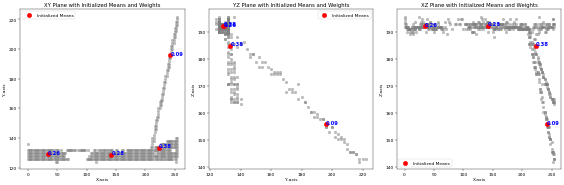

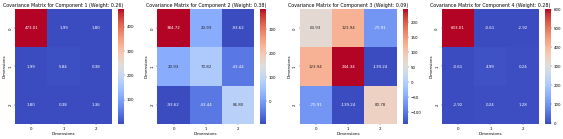

In [66]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans

# Assuming 'data' is a NumPy array with shape (n_samples, 3)
# Uncomment this line and replace with your actual data
# data = np.array([...])

# Define the number of components (4 in your case based on BIC)
optimal_components = 4

# Step 1: Use KMeans to initialize the means
kmeans = KMeans(n_clusters=optimal_components, n_init=10, random_state=42)
kmeans.fit(data)

# The KMeans cluster centers will serve as the initial means for GMM
means_init = kmeans.cluster_centers_

# Step 2: Initialize the weights based on KMeans assignments
labels = kmeans.labels_
counts = np.bincount(labels)
weights_init = counts / len(data)

# Step 3: Initialize the covariances
covariances_init = np.zeros((optimal_components, data.shape[1], data.shape[1]))
for i in range(optimal_components):
    points_in_cluster = data[labels == i]
    covariances_init[i] = np.cov(points_in_cluster, rowvar=False)

# Print the initial means, covariances, and weights
print("Initial Means (from K-Means):")
print(means_init)
print("\nInitial Covariances (from K-Means assignments):")
print(covariances_init)
print("\nInitial Weights (based on K-Means cluster proportions):")
print(weights_init)

# Plotting the initialized means in xy, yz, and xz planes
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# XY Plot
axs[0].scatter(data[:, 0], data[:, 1], color='gray', alpha=0.5)
axs[0].scatter(means_init[:, 0], means_init[:, 1], color='red', s=100, label='Initialized Means')
for i, mean in enumerate(means_init):
    axs[0].text(mean[0], mean[1], f'{weights_init[i]:.2f}', fontsize=12, fontweight='bold', color='blue')
axs[0].set_xlabel('X-axis')
axs[0].set_ylabel('Y-axis')
axs[0].set_title('XY Plane with Initialized Means and Weights')
axs[0].legend()

# YZ Plot
axs[1].scatter(data[:, 1], data[:, 2], color='gray', alpha=0.5)
axs[1].scatter(means_init[:, 1], means_init[:, 2], color='red', s=100, label='Initialized Means')
for i, mean in enumerate(means_init):
    axs[1].text(mean[1], mean[2], f'{weights_init[i]:.2f}', fontsize=12, fontweight='bold', color='blue')
axs[1].set_xlabel('Y-axis')
axs[1].set_ylabel('Z-axis')
axs[1].set_title('YZ Plane with Initialized Means and Weights')
axs[1].legend()

# XZ Plot
axs[2].scatter(data[:, 0], data[:, 2], color='gray', alpha=0.5)
axs[2].scatter(means_init[:, 0], means_init[:, 2], color='red', s=100, label='Initialized Means')
for i, mean in enumerate(means_init):
    axs[2].text(mean[0], mean[2], f'{weights_init[i]:.2f}', fontsize=12, fontweight='bold', color='blue')
axs[2].set_xlabel('X-axis')
axs[2].set_ylabel('Z-axis')
axs[2].set_title('XZ Plane with Initialized Means and Weights')
axs[2].legend()

plt.tight_layout()
plt.show()

# Plotting the initialized covariances as heatmaps in subplots
fig, axs = plt.subplots(1, optimal_components, figsize=(optimal_components * 5, 5))

for i in range(optimal_components):
    sns.heatmap(covariances_init[i], annot=True, fmt=".2f", cmap='coolwarm', ax=axs[i], cbar=True)
    axs[i].set_title(f'Covariance Matrix for Component {i+1} (Weight: {weights_init[i]:.2f})')
    axs[i].set_xlabel('Dimensions')
    axs[i].set_ylabel('Dimensions')

plt.tight_layout()
plt.show()


<u>**Continue reading**</u>

Look at the component 2, xz and yz have negative variances as can be seen as a downward track

Once we initialize the means, weights and covariances we can calculate the responsibility/posterior probability of a data point x to component k. 

This is given  by 

\begin{equation}
\gamma_k = \frac{\pi_{k} \mathcal{N}(x|\mu_k,\Sigma_k)}{\displaystyle\sum_{j=1} ^{K} \pi_{j} \mathcal{N}(x|\mu_j,\Sigma_j)}
\end{equation}

Look at the figure below

C:\Users\alarokia\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\mixture\_base.py:275: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(
Warning tick and label differ 0.5 0.0 for axes #0
Warning tick and label differ 1.5 1.0 for axes #0
Warning tick and label differ 2.5 2.0 for axes #0
Warning tick and label differ 0.5 0.0 for axes #1
Warning tick and label differ 1.5 1.0 for axes #1
Warning tick and label differ 2.5 2.0 for axes #1
Warning tick and label differ 0.5 0.0 for axes #2
Warning tick and label differ 1.5 1.0 for axes #2
Warning tick and label differ 2.5 2.0 for axes #2
Warning tick and label differ 0.5 0.0 for axes #3
Warning tick and label differ 1.5 1.0 for axes #3
Warning tick and label differ 2.5 2.0 for axes #3
Warning tick and label differ 0.5 0.0 for axes #0
Warning tick and label differ 1.5 1.0 for axes #0
Warning tick and lab

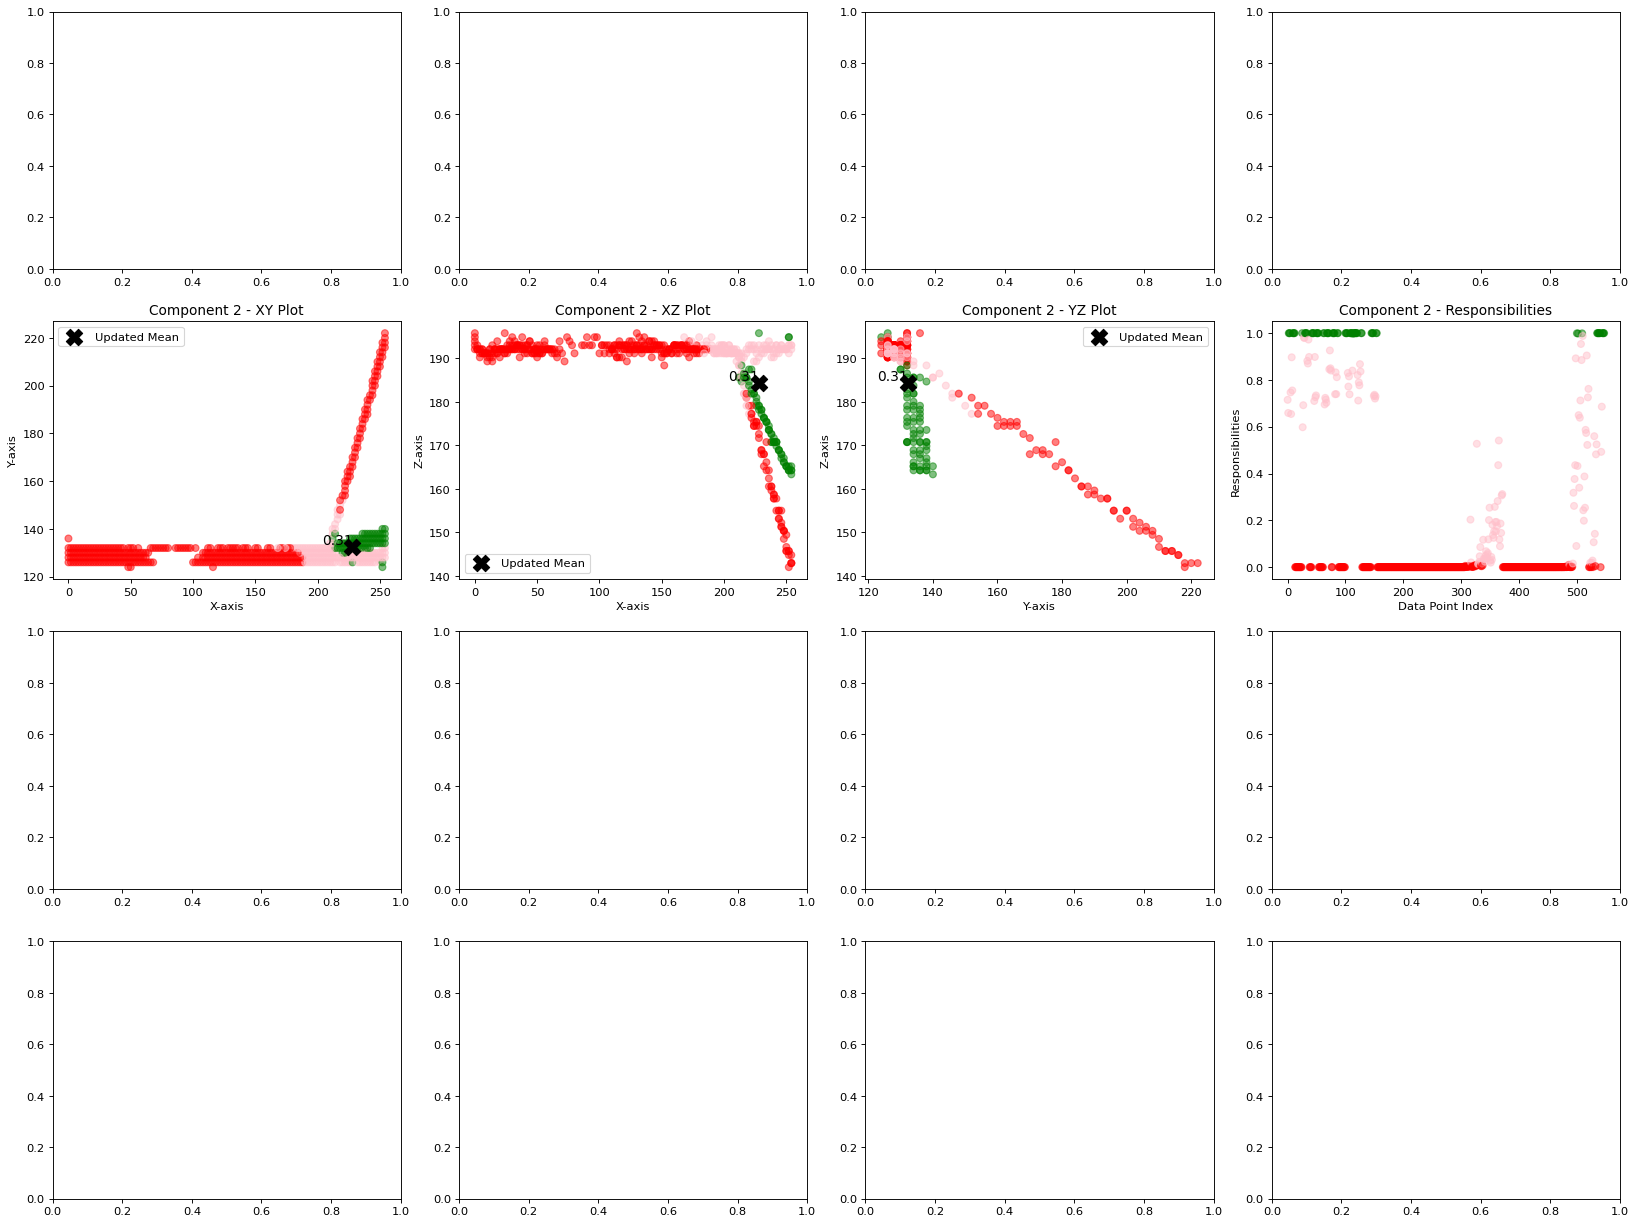

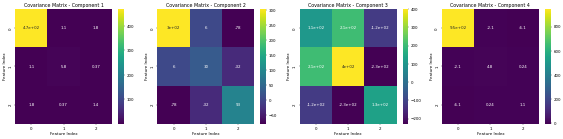

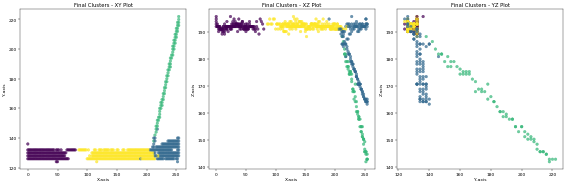

In [68]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans

# Assuming 'data' is your NumPy array with shape (n_samples, 3)
# Uncomment and replace with your actual data
# data = np.array([...])

# Step 1: Use KMeans to initialize the means
optimal_components = 4
kmeans = KMeans(n_clusters=optimal_components, n_init=10, random_state=42)
kmeans.fit(data)

# The KMeans cluster centers will serve as the initial means for GMM
means_init = kmeans.cluster_centers_

# Step 2: Initialize the weights based on KMeans assignments
labels = kmeans.labels_
counts = np.bincount(labels)
weights_init = counts / len(data)

# Initialize GMM with the calculated initial parameters
gmm = GaussianMixture(n_components=optimal_components,
                      means_init=means_init,
                      weights_init=weights_init,
                      covariance_type='full',  # Setting covariance type to 'full'
                      max_iter=1, random_state=42)

# Fit the GMM
gmm.fit(data)

# Get responsibilities, means, covariances, and weights
responsibilities = gmm.predict_proba(data)
means = gmm.means_
weights = gmm.weights_
covariances = gmm.covariances_

# Set a tolerance level for floating-point comparison
tolerance = 0.01

# Prepare the plot for scatter plots with updated means and weights
fig, axs = plt.subplots(4, 4, figsize=(20, 15))
component_labels = ['Component 1', 'Component 2', 'Component 3', 'Component 4']

for i in range(optimal_components):
    if i == 1:
        # Determine colors based on responsibilities
        colors = np.where(responsibilities[:, i] > (1 - tolerance), 'green',  # Responsibility close to 1
                          np.where(responsibilities[:, i] < tolerance, 'red',  # Responsibility close to 0
                                   'pink'))  # Soft assignment

        data_x_for_plot_1 = data[:, 0]
        data_y_for_plot_1 = data[:, 1]
        colors_for_plot_1 = colors
        means_x_for_plot_1 = means[i, 0]
        means_y_for_plot_1 = means[i, 1]
        weights_for_plot_1 = weights[i]
        respon_x_for_plot_1 = range(len(responsibilities))
        respon_y_for_plot_1 = responsibilities[:, i]
        
        # Scatter plots in xy, xz, and yz
        axs[i, 0].scatter(data[:, 0], data[:, 1], color=colors, alpha=0.5)
        axs[i, 0].set_title(f"{component_labels[i]} - XY Plot")
        axs[i, 0].set_xlabel('X-axis')
        axs[i, 0].set_ylabel('Y-axis')
        axs[i, 0].scatter(means[i, 0], means[i, 1], color='black', marker='X', s=200, label='Updated Mean')
        axs[i, 0].text(means[i, 0], means[i, 1], f"{weights[i]:.2f}", fontsize=12, ha='right', va='bottom', color='black')
        axs[i, 0].legend()


        axs[i, 1].scatter(data[:, 0], data[:, 2], color=colors, alpha=0.5)
        axs[i, 1].set_title(f"{component_labels[i]} - XZ Plot")
        axs[i, 1].set_xlabel('X-axis')
        axs[i, 1].set_ylabel('Z-axis')
        axs[i, 1].scatter(means[i, 0], means[i, 2], color='black', marker='X', s=200, label='Updated Mean')
        axs[i, 1].text(means[i, 0], means[i, 2], f"{weights[i]:.2f}", fontsize=12, ha='right', va='bottom', color='black')
        axs[i, 1].legend()

        axs[i, 2].scatter(data[:, 1], data[:, 2], color=colors, alpha=0.5)
        axs[i, 2].set_title(f"{component_labels[i]} - YZ Plot")
        axs[i, 2].set_xlabel('Y-axis')
        axs[i, 2].set_ylabel('Z-axis')
        axs[i, 2].scatter(means[i, 1], means[i, 2], color='black', marker='X', s=200, label='Updated Mean')
        axs[i, 2].text(means[i, 1], means[i, 2], f"{weights[i]:.2f}", fontsize=12, ha='right', va='bottom', color='black')
        axs[i, 2].legend()

        # Plot responsibilities vs data indices
        axs[i, 3].scatter(range(len(responsibilities)), responsibilities[:, i], color=colors, alpha=0.5)
        axs[i, 3].set_title(f"{component_labels[i]} - Responsibilities")
        axs[i, 3].set_xlabel('Data Point Index')
        axs[i, 3].set_ylabel('Responsibilities')

plt.tight_layout()
plt.show()

# Plot covariance matrices as heatmaps in a separate figure
fig, axs = plt.subplots(1, optimal_components, figsize=(20, 5))
for i in range(optimal_components):
    sns.heatmap(covariances[i], ax=axs[i], cmap='viridis', annot=True, cbar=True)
    axs[i].set_title(f"Covariance Matrix - {component_labels[i]}")
    axs[i].set_xlabel('Feature Index')
    axs[i].set_ylabel('Feature Index')

plt.tight_layout()
plt.show()

# Scatter plot of the final clusters identified by GMM
cluster_labels = gmm.predict(data)  # Predict the cluster for each point based on the final fit
cluster_labels_plot_1 = cluster_labels
data_x_scatter_plot_1 = data[:, 0]
data_y_scatter_plot_1 = data[:, 1]
data_z_scatter_plot_1 = data[:, 2]

fig, ax = plt.subplots(1, 3, figsize=(18, 6))

# Plot xy, xz, and yz projections with clusters colored
ax[0].scatter(data[:, 0], data[:, 1], c=cluster_labels, cmap='viridis', alpha=0.7)
ax[0].set_title("Final Clusters - XY Plot")
ax[0].set_xlabel('X-axis')
ax[0].set_ylabel('Y-axis')

ax[1].scatter(data[:, 0], data[:, 2], c=cluster_labels, cmap='viridis', alpha=0.7)
ax[1].set_title("Final Clusters - XZ Plot")
ax[1].set_xlabel('X-axis')
ax[1].set_ylabel('Z-axis')

ax[2].scatter(data[:, 1], data[:, 2], c=cluster_labels, cmap='viridis', alpha=0.7)
ax[2].set_title("Final Clusters - YZ Plot")
ax[2].set_xlabel('Y-axis')
ax[2].set_ylabel('Z-axis')

plt.tight_layout()
plt.show()

<u>**Continue reading**</u>

In the figure above, we can see the calculated responsibility (column 4 in the subplot) of each data point x to component k.  
Green is having full responsibility of x to k (posterior probability = 1)  
Pink is a soft assignment (posterior probability between 0 and 1)  
Red is no responsibility (posterior probability = 1)  
The updated mean is marked by a black cross and the updated weight/prior is marked by a text  
The updated mean for example is the weighted average of the data points, with the weights being the responsibilities.
Pay attention to points between x = 50 and x = 100. They are mostly pink and are likely to belong to either component 4 or component 1  (look at subplot row 4 column 1)  
These points are assigned based on which component has the highest posterior probability of having generated x.  
In the final plot, you can see half of these points are assigned to component 1 and the other half is assigned to component 4. 
This is the just the result of the first iteration. 

The iteration (of calculating the posterior probability/responsibility - step expectation, and of recalculating $\mu_k$, $\Sigma_k$, $\pi_k$ - step maximization)  
continues until convergence (no large change in the estimated parameters ($\mu_k$, $\Sigma_k$, $\pi_k$) of the model)

Look at how component 2 in blue has multiple points assigned from component 4 (Yellow) and component 2 (Green)
Follow this in the next figure, which shows the result after second iteration

C:\Users\alarokia\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\mixture\_base.py:275: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(
Warning tick and label differ 0.5 0.0 for axes #0
Warning tick and label differ 1.5 1.0 for axes #0
Warning tick and label differ 2.5 2.0 for axes #0
Warning tick and label differ 0.5 0.0 for axes #1
Warning tick and label differ 1.5 1.0 for axes #1
Warning tick and label differ 2.5 2.0 for axes #1
Warning tick and label differ 0.5 0.0 for axes #2
Warning tick and label differ 1.5 1.0 for axes #2
Warning tick and label differ 2.5 2.0 for axes #2
Warning tick and label differ 0.5 0.0 for axes #3
Warning tick and label differ 1.5 1.0 for axes #3
Warning tick and label differ 2.5 2.0 for axes #3
Warning tick and label differ 0.5 0.0 for axes #0
Warning tick and label differ 1.5 1.0 for axes #0
Warning tick and lab

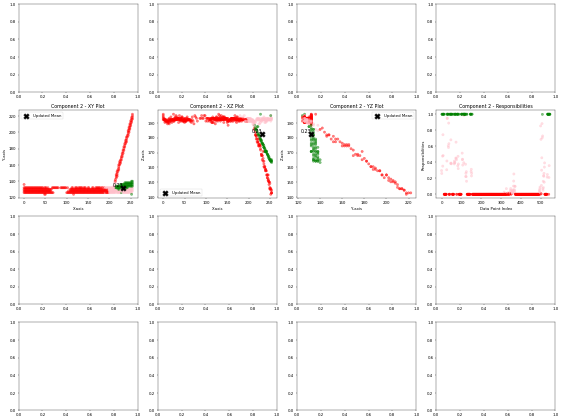

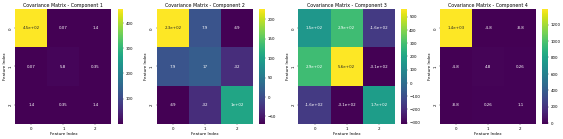

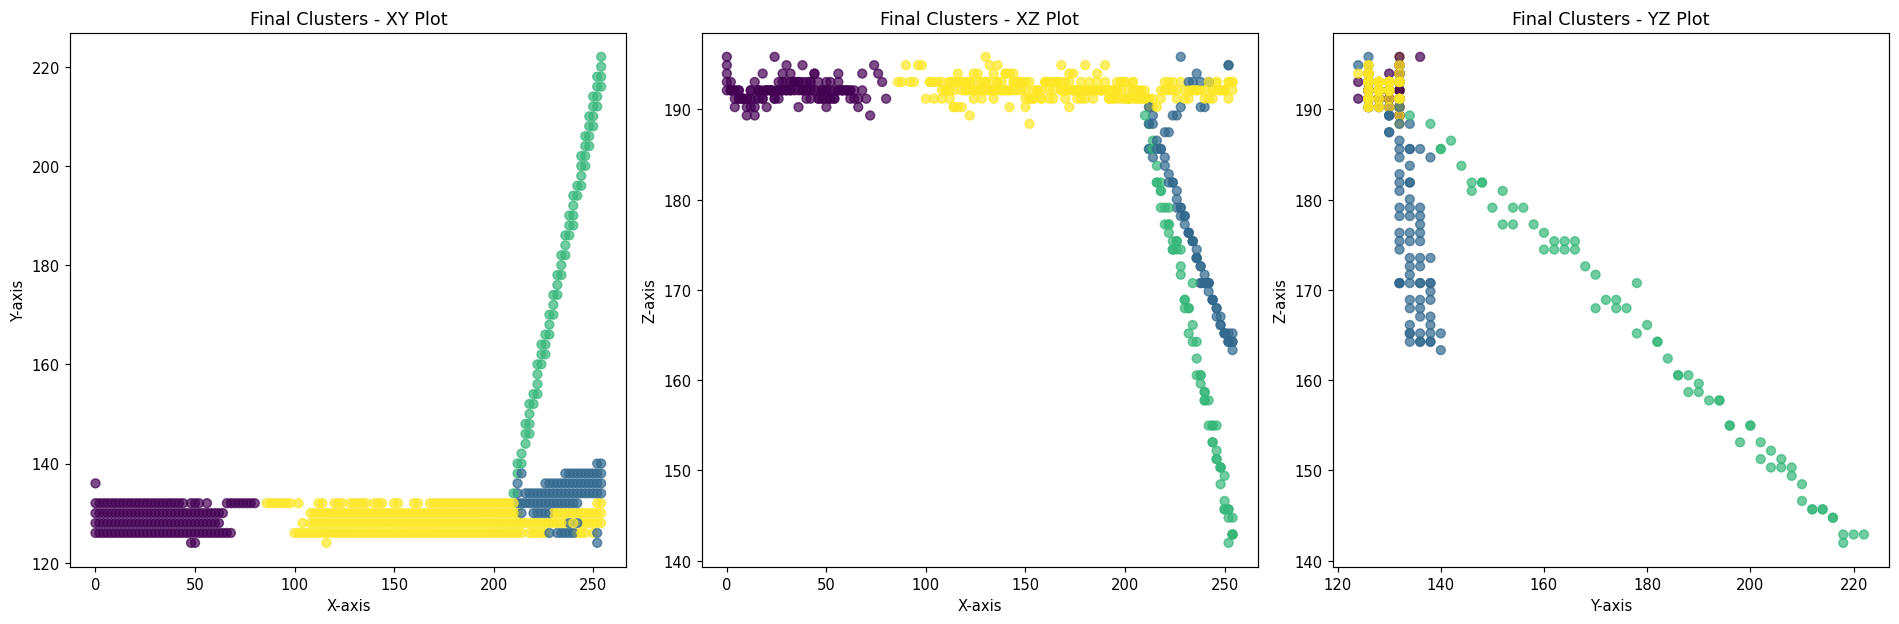

In [69]:
# Initialize GMM with the calculated initial parameters
gmm = GaussianMixture(n_components=optimal_components,
                      means_init=means_init,
                      weights_init=weights_init,
                      covariance_type='full',  # Setting covariance type to 'full'
                      max_iter=2, random_state=42)

# Fit the GMM
gmm.fit(data)

# Get responsibilities, means, covariances, and weights
responsibilities = gmm.predict_proba(data)
means = gmm.means_
weights = gmm.weights_
covariances = gmm.covariances_

# Set a tolerance level for floating-point comparison
tolerance = 0.01

# Prepare the plot for scatter plots with updated means and weights
fig, axs = plt.subplots(4, 4, figsize=(20, 15))
component_labels = ['Component 1', 'Component 2', 'Component 3', 'Component 4']

for i in range(optimal_components):
    # Determine colors based on responsibilities
    if i == 1:
        
        colors = np.where(responsibilities[:, i] > (1 - tolerance), 'green',  # Responsibility close to 1
                          np.where(responsibilities[:, i] < tolerance, 'red',  # Responsibility close to 0
                                   'pink'))  # Soft assignment

        data_x_for_plot_2 = data[:, 0]
        data_y_for_plot_2 = data[:, 1]
        colors_for_plot_2 = colors
        means_x_for_plot_2 = means[i, 0]
        means_y_for_plot_2 = means[i, 1]
        weights_for_plot_2 = weights[i]
        respon_x_for_plot_2 = range(len(responsibilities))
        respon_y_for_plot_2 = responsibilities[:, i]

        # Scatter plots in xy, xz, and yz
        axs[i, 0].scatter(data[:, 0], data[:, 1], color=colors, alpha=0.5)
        axs[i, 0].set_title(f"{component_labels[i]} - XY Plot")
        axs[i, 0].set_xlabel('X-axis')
        axs[i, 0].set_ylabel('Y-axis')
        axs[i, 0].scatter(means[i, 0], means[i, 1], color='black', marker='X', s=200, label='Updated Mean')
        axs[i, 0].text(means[i, 0], means[i, 1], f"{weights[i]:.2f}", fontsize=12, ha='right', va='bottom', color='black')
        axs[i, 0].legend()

        axs[i, 1].scatter(data[:, 0], data[:, 2], color=colors, alpha=0.5)
        axs[i, 1].set_title(f"{component_labels[i]} - XZ Plot")
        axs[i, 1].set_xlabel('X-axis')
        axs[i, 1].set_ylabel('Z-axis')
        axs[i, 1].scatter(means[i, 0], means[i, 2], color='black', marker='X', s=200, label='Updated Mean')
        axs[i, 1].text(means[i, 0], means[i, 2], f"{weights[i]:.2f}", fontsize=12, ha='right', va='bottom', color='black')
        axs[i, 1].legend()

        axs[i, 2].scatter(data[:, 1], data[:, 2], color=colors, alpha=0.5)
        axs[i, 2].set_title(f"{component_labels[i]} - YZ Plot")
        axs[i, 2].set_xlabel('Y-axis')
        axs[i, 2].set_ylabel('Z-axis')
        axs[i, 2].scatter(means[i, 1], means[i, 2], color='black', marker='X', s=200, label='Updated Mean')
        axs[i, 2].text(means[i, 1], means[i, 2], f"{weights[i]:.2f}", fontsize=12, ha='right', va='bottom', color='black')
        axs[i, 2].legend()

        # Plot responsibilities vs data indices
        axs[i, 3].scatter(range(len(responsibilities)), responsibilities[:, i], color=colors, alpha=0.5)
        axs[i, 3].set_title(f"{component_labels[i]} - Responsibilities")
        axs[i, 3].set_xlabel('Data Point Index')
        axs[i, 3].set_ylabel('Responsibilities')

plt.tight_layout()
plt.show()

# Plot covariance matrices as heatmaps in a separate figure
fig, axs = plt.subplots(1, optimal_components, figsize=(20, 5))
for i in range(optimal_components):
    sns.heatmap(covariances[i], ax=axs[i], cmap='viridis', annot=True, cbar=True)
    axs[i].set_title(f"Covariance Matrix - {component_labels[i]}")
    axs[i].set_xlabel('Feature Index')
    axs[i].set_ylabel('Feature Index')

plt.tight_layout()
plt.show()

# Scatter plot of the final clusters identified by GMM
cluster_labels = gmm.predict(data)  # Predict the cluster for each point based on the final fit

cluster_labels_plot_2 = cluster_labels
data_x_scatter_plot_2 = data[:, 0]
data_y_scatter_plot_2 = data[:, 1]
data_z_scatter_plot_2 = data[:, 2]

fig, ax = plt.subplots(1, 3, figsize=(18, 6))

# Plot xy, xz, and yz projections with clusters colored
ax[0].scatter(data[:, 0], data[:, 1], c=cluster_labels, cmap='viridis', alpha=0.7)
ax[0].set_title("Final Clusters - XY Plot")
ax[0].set_xlabel('X-axis')
ax[0].set_ylabel('Y-axis')

ax[1].scatter(data[:, 0], data[:, 2], c=cluster_labels, cmap='viridis', alpha=0.7)
ax[1].set_title("Final Clusters - XZ Plot")
ax[1].set_xlabel('X-axis')
ax[1].set_ylabel('Z-axis')

ax[2].scatter(data[:, 1], data[:, 2], c=cluster_labels, cmap='viridis', alpha=0.7)
ax[2].set_title("Final Clusters - YZ Plot")
ax[2].set_xlabel('Y-axis')
ax[2].set_ylabel('Z-axis')

plt.tight_layout()
plt.show()

<u>**Continue reading**</u>

If you followed the blue component in the first iteration, you can see the changes in the assignment. Finally you can look at the final result

C:\Users\alarokia\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\mixture\_base.py:275: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


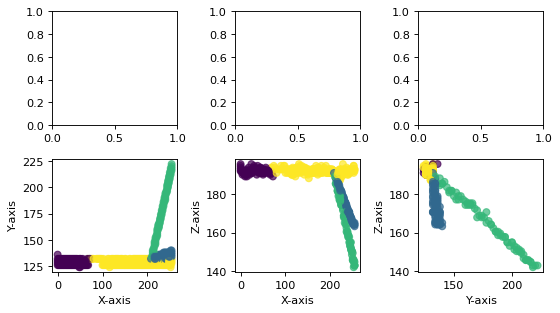

In [56]:
# Initialize GMM with the calculated initial parameters
gmm = GaussianMixture(n_components=optimal_components,
                      means_init=means_init,
                      weights_init=weights_init,
                      covariance_type='full',  # Setting covariance type to 'full'
                      max_iter=11, random_state=42)

# Fit the GMM
gmm.fit(data)

# Get responsibilities, means, covariances, and weights
responsibilities = gmm.predict_proba(data)
means = gmm.means_
weights = gmm.weights_
covariances = gmm.covariances_

# # Set a tolerance level for floating-point comparison
# tolerance = 0.01

# # Prepare the plot for scatter plots with updated means and weights
# fig, axs = plt.subplots(4, 4, figsize=(20, 15))
# component_labels = ['Component 1', 'Component 2', 'Component 3', 'Component 4']

# for i in range(optimal_components):
#     # Determine colors based on responsibilities
#     colors = np.where(responsibilities[:, i] > (1 - tolerance), 'green',  # Responsibility close to 1
#                       np.where(responsibilities[:, i] < tolerance, 'red',  # Responsibility close to 0
#                                'pink'))  # Soft assignment
    
#     # Scatter plots in xy, xz, and yz
#     axs[i, 0].scatter(data[:, 0], data[:, 1], color=colors, alpha=0.5)
#     axs[i, 0].set_title(f"{component_labels[i]} - XY Plot")
#     axs[i, 0].set_xlabel('X-axis')
#     axs[i, 0].set_ylabel('Y-axis')
#     axs[i, 0].scatter(means[i, 0], means[i, 1], color='black', marker='X', s=200, label='Updated Mean')
#     axs[i, 0].text(means[i, 0], means[i, 1], f"{weights[i]:.2f}", fontsize=12, ha='right', va='bottom', color='black')
#     axs[i, 0].legend()

#     axs[i, 1].scatter(data[:, 0], data[:, 2], color=colors, alpha=0.5)
#     axs[i, 1].set_title(f"{component_labels[i]} - XZ Plot")
#     axs[i, 1].set_xlabel('X-axis')
#     axs[i, 1].set_ylabel('Z-axis')
#     axs[i, 1].scatter(means[i, 0], means[i, 2], color='black', marker='X', s=200, label='Updated Mean')
#     axs[i, 1].text(means[i, 0], means[i, 2], f"{weights[i]:.2f}", fontsize=12, ha='right', va='bottom', color='black')
#     axs[i, 1].legend()

#     axs[i, 2].scatter(data[:, 1], data[:, 2], color=colors, alpha=0.5)
#     axs[i, 2].set_title(f"{component_labels[i]} - YZ Plot")
#     axs[i, 2].set_xlabel('Y-axis')
#     axs[i, 2].set_ylabel('Z-axis')
#     axs[i, 2].scatter(means[i, 1], means[i, 2], color='black', marker='X', s=200, label='Updated Mean')
#     axs[i, 2].text(means[i, 1], means[i, 2], f"{weights[i]:.2f}", fontsize=12, ha='right', va='bottom', color='black')
#     axs[i, 2].legend()

#     # Plot responsibilities vs data indices
#     axs[i, 3].scatter(range(len(responsibilities)), responsibilities[:, i], color=colors, alpha=0.5)
#     axs[i, 3].set_title(f"{component_labels[i]} - Responsibilities")
#     axs[i, 3].set_xlabel('Data Point Index')
#     axs[i, 3].set_ylabel('Responsibilities')

# # plt.tight_layout()
# # plt.show()

# # Plot covariance matrices as heatmaps in a separate figure
# fig, axs = plt.subplots(1, optimal_components, figsize=(20, 5))
# for i in range(optimal_components):
#     sns.heatmap(covariances[i], ax=axs[i], cmap='viridis', annot=True, cbar=True)
#     axs[i].set_title(f"Covariance Matrix - {component_labels[i]}")
#     axs[i].set_xlabel('Feature Index')
#     axs[i].set_ylabel('Feature Index')

# # plt.tight_layout()
# # plt.show()

# Scatter plot of the final clusters identified by GMM
cluster_labels = gmm.predict(data)  # Predict the cluster for each point based on the final fit

fig, ax = plt.subplots(2, 3, figsize=(7, 4))

# ax[0, 0].scatter(data_orig[:,0], data_orig[:,1], color='grey', alpha=0.7, s = 10)
# ax[0, 0].scatter(data_db[:,0], data_db[:,1], alpha=0.7, s = 10)

# ax[0, 1].plot(data_kneedle[:,0], data_kneedle[:,1])

# ax[0, 2].plot(a,b)


# Plot xy, xz, and yz projections with clusters colored
ax[1, 0].scatter(data[:, 0], data[:, 1], c=cluster_labels, cmap='viridis', alpha=0.7)
# ax[1, 0].set_title("Final Clusters - XY Plot")
ax[1, 0].set_xlabel('X-axis')
ax[1, 0].set_ylabel('Y-axis')

ax[1, 1].scatter(data[:, 0], data[:, 2], c=cluster_labels, cmap='viridis', alpha=0.7)
# ax[1, 1].set_title("Final Clusters - XZ Plot")
ax[1, 1].set_xlabel('X-axis')
ax[1, 1].set_ylabel('Z-axis')

ax[1, 2].scatter(data[:, 1], data[:, 2], c=cluster_labels, cmap='viridis', alpha=0.7)
# ax[1, 2].set_title("Final Clusters - YZ Plot")
ax[1, 2].set_xlabel('Y-axis')
ax[1, 2].set_ylabel('Z-axis')

plt.tight_layout()
plt.show()

C:\Users\alarokia\AppData\Local\Temp\ipykernel_516\3013882108.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap(cmap, len(unique_labels))
C:\Users\alarokia\AppData\Local\Temp\ipykernel_516\3013882108.py:105: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


eval plt.figure(1).axes[0].set(position=[0.06698, 0.5633, 0.2475, 0.3867], xscale='linear', xlabel='X [mm]', xlim=(-2., 256.), yscale='linear', ylabel='Y [mm]', ylim=(1., 220.), zorder=0)
eval plt.figure(1).axes[0].set_xticks([], [], minor=True)
eval plt.figure(1).axes[0].set_yticks([], [], minor=True)
eval plt.figure(1).axes[0].grid(False)
eval plt.figure(1).axes[0].spines[['left', 'right', 'bottom', 'top']].set_visible(True)
eval plt.figure(1).axes[0].set(position=[0.06698, 0.5633, 0.2475, 0.3867], xscale='linear', xlabel='X [mm]', xlim=(-2., 256.), yscale='linear', ylabel='Y [mm]', ylim=(12., 220.), zorder=0)
eval plt.figure(1).axes[0].set_xticks([], [], minor=True)
eval plt.figure(1).axes[0].set_yticks([], [], minor=True)
eval plt.figure(1).axes[0].grid(False)
eval plt.figure(1).axes[0].spines[['left', 'right', 'bottom', 'top']].set_visible(True)
eval plt.figure(1).axes[0].set(position=[0.06698, 0.5633, 0.2475, 0.3867], xscale='linear', xlabel='X [mm]', xlim=(-2., 256.), yscale='li

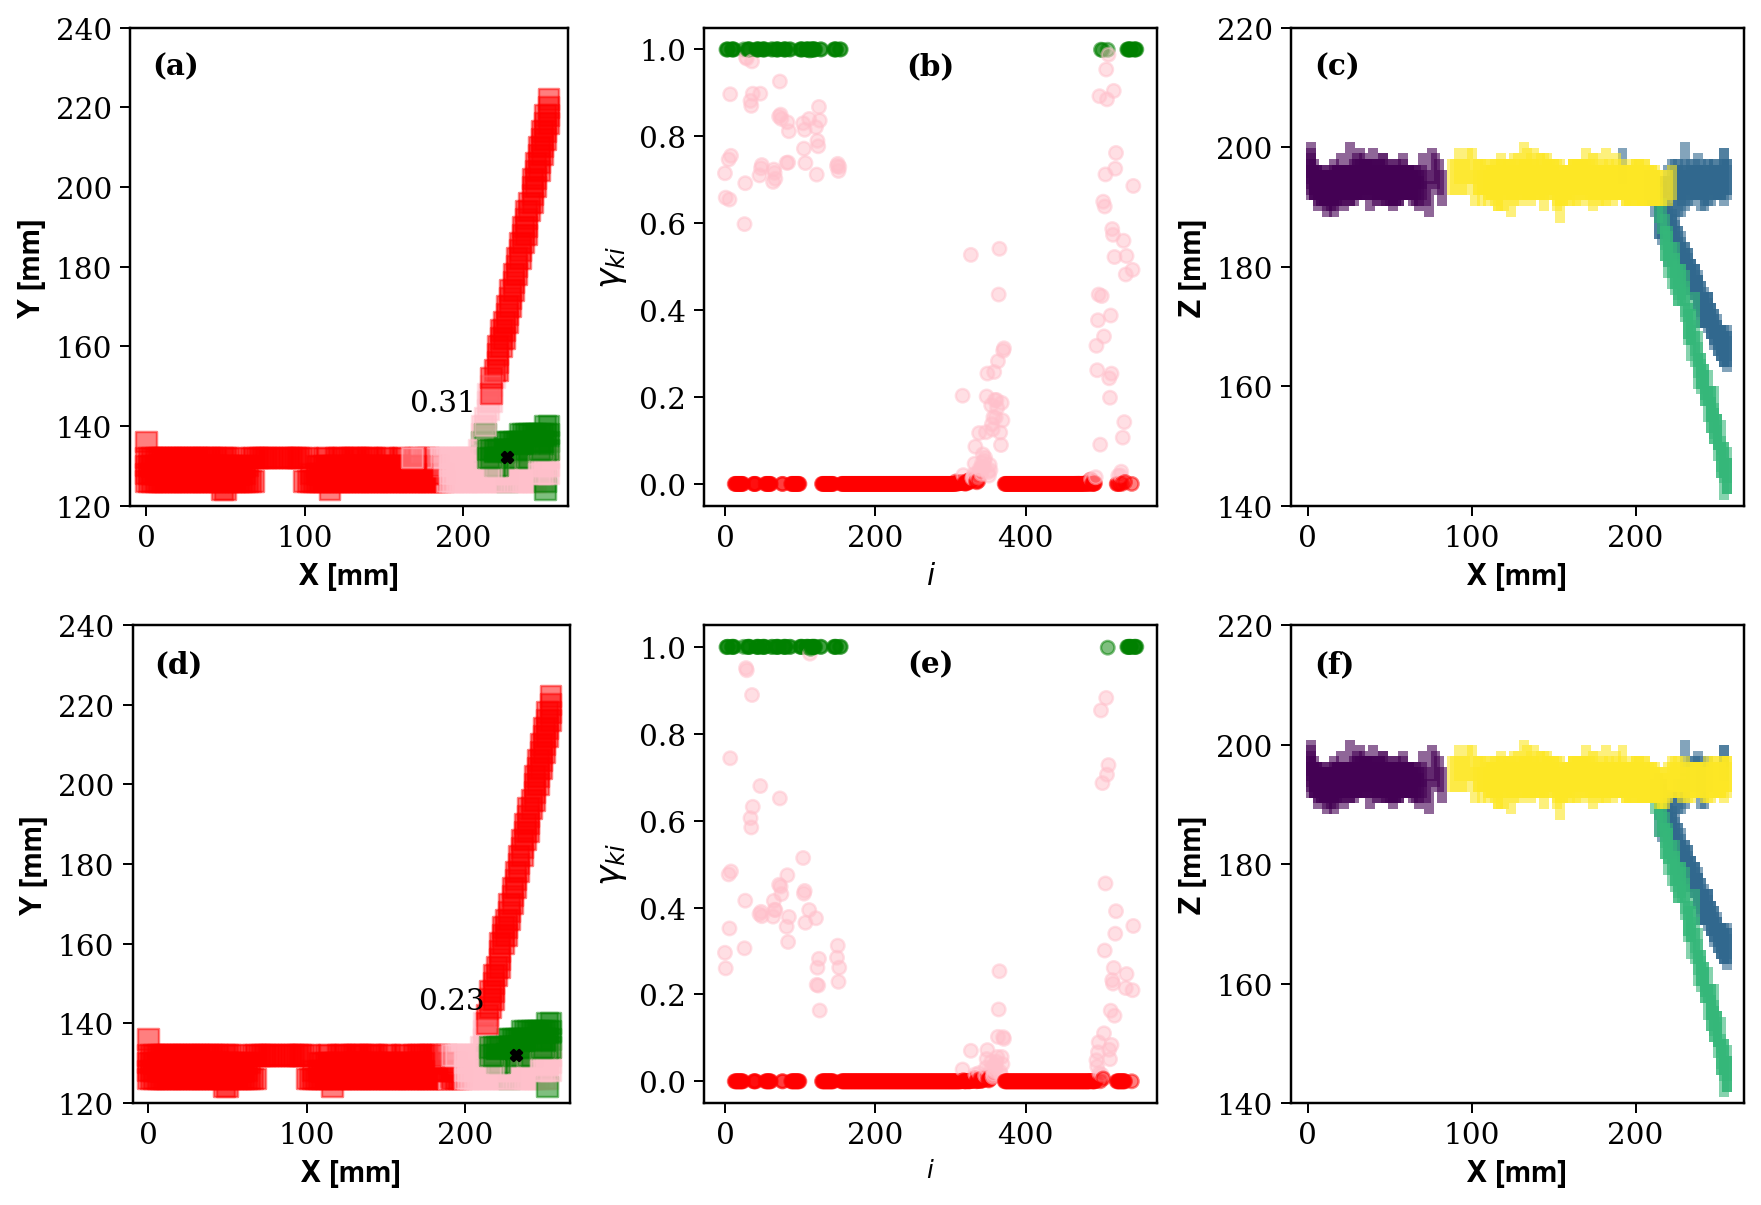

In [88]:
from matplotlib.patches import Rectangle
from matplotlib import rcParams
# import pylustrator
# pylustrator.start()
# fig, axes = plt.subplots(2, 3, figsize=(6.5, 4))

# Function to plot squares in a given axes
def plot_squares(ax, X_data, Y_data, labels, cmap='viridis'):
    unique_labels = np.unique(labels)
    colors = plt.cm.get_cmap(cmap, len(unique_labels))
    
    for k in unique_labels:
        subset_X = X_data[labels == k]
        subset_Y = Y_data[labels == k]
        for x, y in zip(subset_X, subset_Y):
            rect = Rectangle(
                (x - 1, y - 1),  # bottom-left corner; 2mm square
                6, 6,             # width, height in data units
                facecolor=colors(k) if k != -1 else 'k',
                edgecolor='none',
                alpha=0.6,
                linewidth=0.0
            )
            ax.add_patch(rect)
    
    # ax.set_aspect('equal')  # ensure squares look square
    ax.set_xlabel(ax.get_xlabel())
    ax.set_ylabel(ax.get_ylabel())

# --- GLOBAL STYLE FOR NIMA-STYLE PLOTS ---
rcParams["font.size"] = 12
rcParams["font.family"] = "serif"
rcParams["axes.labelweight"] = "bold"
rcParams["axes.linewidth"] = 1.0
rcParams["xtick.major.size"] = 4
rcParams["ytick.major.size"] = 4

fig = plt.figure(figsize=(10, 7))

# Define grid with controlled spacing
gs = fig.add_gridspec(
    2, 3,
    left=0.05, right=0.98, top=0.95, bottom=0.08,
    wspace=0.25, hspace=0.25
)

axes = np.empty((2,3), dtype=object)

for i in range(2):
    for j in range(3):
        axes[i, j] = fig.add_subplot(gs[i, j])

# font_properties = {'family': 'Arial', 'size': 10, 'weight': 'bold'}

axes[0, 0].cla()
axes[0, 0].scatter(data_x_for_plot_1, data_y_for_plot_1, color=colors_for_plot_1, alpha=0.5, marker='s', s= 70)
axes[0, 0].set_xlabel('X [mm]', fontdict=font_properties)
axes[0, 0].set_ylabel('Y [mm]', fontdict=font_properties)
axes[0, 0].scatter(means_x_for_plot_1, means_y_for_plot_1, color='black', marker='X', s=20, label='Updated Mean')
axes[0, 0].text(means_x_for_plot_1-20, means_y_for_plot_1+10, f"{weights_for_plot_1:.2f}", fontsize=12, ha='right', va='bottom', color='black')
axes[0, 0].text(0.05, 0.95, '(a)', transform=axes[0, 0].transAxes, fontsize=12, weight='bold', ha='left', va='top')
axes[0, 0].set_xlim(np.min(data_x_for_plot_1) - 2, np.max(data_x_for_plot_1) + 2)
axes[0, 0].set_ylim(100, 220)

axes[1, 0].cla()
# plot_squares(axes[1, 0], data_x_for_plot_2, data_y_for_plot_2, colors_for_plot_2)
axes[1, 0].scatter(data_x_for_plot_2, data_y_for_plot_2, color=colors_for_plot_2, alpha=0.5, marker='s', s= 70)
axes[1, 0].set_xlabel('X [mm]', fontdict=font_properties)
axes[1, 0].set_ylabel('Y [mm]', fontdict=font_properties)
axes[1, 0].scatter(means_x_for_plot_2, means_y_for_plot_2, color='black', marker='X', s=20, label='Updated Mean')
axes[1, 0].text(means_x_for_plot_2-20, means_y_for_plot_2+10, f"{weights_for_plot_2:.2f}", fontsize=12, ha='right', va='bottom', color='black')
axes[1, 0].text(0.05, 0.95, '(d)', transform=axes[1, 0].transAxes, fontsize=12, weight='bold', ha='left', va='top')
axes[1, 0].set_xlim(np.min(data_x_for_plot_2) - 2, np.max(data_x_for_plot_2) + 2)
axes[1, 0].set_ylim(100, 220)

axes[0, 1].scatter(respon_x_for_plot_1, respon_y_for_plot_1, color=colors_for_plot_1, alpha=0.5, s=30)
axes[0, 1].set_xlabel(r'$i$', fontdict=font_properties)
axes[0, 1].set_ylabel(r'$\gamma_{ki}$', fontdict=font_properties)
axes[0, 1].text(0.5, 0.95, '(b)', transform=axes[0, 1].transAxes, fontsize=12, weight='bold', ha='center', va='top')

axes[1, 1].scatter(respon_x_for_plot_2, respon_y_for_plot_2, color=colors_for_plot_2, alpha=0.5, s=30)
axes[1, 1].set_xlabel(r'$i$', fontdict=font_properties)
axes[1, 1].set_ylabel(r'$\gamma_{ki}$', fontdict=font_properties)
axes[1, 1].text(0.5, 0.95, '(e)', transform=axes[1, 1].transAxes, fontsize=12, weight='bold', ha='center', va='top')

axes[0, 2].cla()
plot_squares(axes[0, 2], data_x_scatter_plot_1, data_z_scatter_plot_1, cluster_labels_plot_1)
# axes[0,2].scatter(data_x_scatter_plot_1, data_z_scatter_plot_1, c=cluster_labels_plot_1, cmap='viridis', alpha=0.7, s= 70, marker='s')
axes[0,2].set_xlabel('X [mm]', fontdict=font_properties)
axes[0,2].set_ylabel('Z [mm]', fontdict=font_properties)
axes[0, 2].text(0.05, 0.95, '(c)', transform=axes[0, 2].transAxes, fontsize=12, weight='bold', ha='left', va='top')
axes[0, 2].set_xlim(0, 250)
axes[0, 2].set_ylim(150, 220)

axes[1, 2].cla()
plot_squares(axes[1, 2], data_x_scatter_plot_2, data_z_scatter_plot_2, cluster_labels_plot_2)
# axes[1,2].scatter(data_x_scatter_plot_2, data_z_scatter_plot_2, c=cluster_labels_plot_2, cmap='viridis', alpha=0.7, s= 70, marker='s')
axes[1,2].set_xlabel('X [mm]', fontdict=font_properties)
axes[1,2].set_ylabel('Z [mm]', fontdict=font_properties)
axes[1, 2].text(0.05, 0.95, '(f)', transform=axes[1, 2].transAxes, fontsize=12, weight='bold', ha='left', va='top')
axes[1, 2].set_xlim(0, 250)
axes[1, 2].set_ylim(150, 220)


plt.tight_layout()
plt.savefig('gmm_resp.png', dpi=300, bbox_inches='tight')
plt.show()